In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import contourpy
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter
import numpy as np
from _FigureJiazeHelper import *
from _DetectabilityWithMeta import *
from _CommunityDetect import *
from EXPERIMENT_MINORITY import *
from scipy.optimize import linear_sum_assignment

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 10  # 'large'
plt.rcParams['lines.markersize'] = 12
plt.rcParams['axes.linewidth'] = 0.5

# %matplotlib notebook
%config InlineBackend.figure_format = 'retina'

# resolution limit vs minority detectability of BH
No relationship

In [6]:
n = 6000
d = 15
Z_s = 2
Z_b = 2
q = Z_s + Z_b

rhos = np.setdiff1d(np.around(np.linspace(0, 0.5, 42), 2), np.array([0, 0.5]))
max_delta = max([(d/n)/((1-r)**2/Z_b+r**2/Z_s) for r in rhos])
min_delta = min([(d/n)/((1-r)**2/Z_b+r**2/Z_s-1) for r in rhos])
deltas = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, 60), 5), np.array([]))
# print(rhos, deltas)

lambdas = np.zeros((np.size(deltas) * np.size(rhos), 4))
max_snr = 0
i = 0
for rho in rhos:
    for delta in deltas:
        pout = d / n - ((1-rho)**2 / Z_b + rho**2 / Z_s) * delta
        pin = pout + delta
        # if pin < 0 or pin > 1 or pout < 0 or pout > 1:
        #     # print(f'{rho} {delta}')
        #     lambdas[i, :] = [1, np.inf, np.inf, np.inf]
        # else:
        ps = (pin - pout) * np.identity(q) + pout * np.ones((q, q))
        P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
        Q = n * ps
        lambdas[i, :] = MetaSBM.get_lambdas_general(P, Q)
        max_snr = lambdas[i, 1]**2/lambdas[i, 0] if lambdas[i, 1]**2/lambdas[i, 0] > max_snr else max_snr
        i += 1
plot_rhos = np.repeat(rhos, np.size(deltas))
plot_zs = np.tile(deltas, np.size(rhos))

reso_limit_rho = np.sqrt(n * d) / n
print(reso_limit_rho)

0.05


minz=0, maxz=18.06913718841281, cticks=[0, 1], clabel=['0', '18.0']


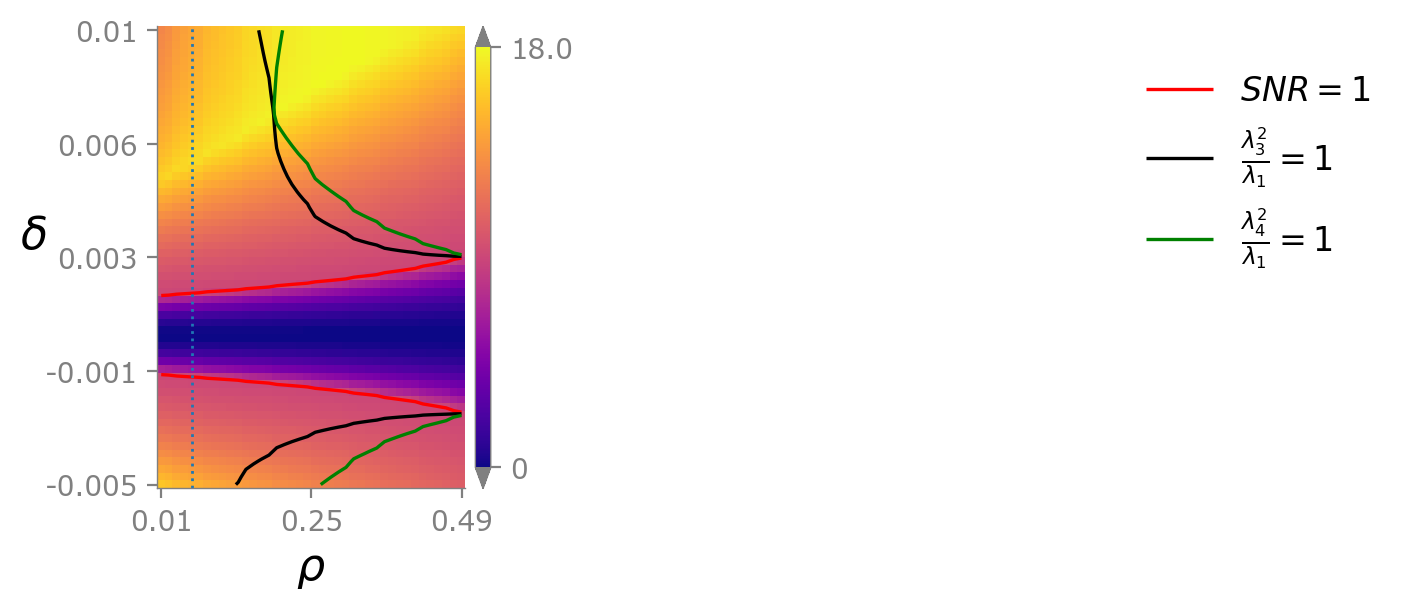

In [7]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=max_snr, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=max_snr, ytickprecision=3, cticks=[0, 1])

handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
ax.axvline((reso_limit_rho)/(0.5)*np.size(np.unique(plot_rhos)), linestyle=':', lw=1)
lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# plt.subplots_adjust(wspace=0.8)
# save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'Z_s{Z_s}Z_b{Z_b}' + "_half.pdf"
# # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# BP, BH learn q by MDL, FE, NegEig of BH

In [3]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b

rhos = np.setdiff1d(np.around(np.linspace(0, 0.5, 42), 3), np.array([0, 0.5]))
# min_delta = (Z_s + Z_b) * d / ((1 - Z_s - Z_b) * n)
min_delta = 0
max_delta = min(Z_s, Z_b) * d / n
deltas = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, 40), 5), np.array([]))
print(rhos, deltas)

lambdas = np.zeros((np.size(deltas) * np.size(rhos), 4))
max_snr = 0
i = 0
exp_run_i = 0
for rho in rhos:
    for delta in deltas:
        pout = d / n - ((1-rho)**2 / Z_b + rho**2 / Z_s) * delta
        pin = pout + delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            # print(f'{rho} {delta}')
            lambdas[i, :] = [1, np.inf, np.inf, np.inf]
        else:
            ps = (pin - pout) * np.identity(q) + pout * np.ones((q, q))
            P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
            Q = n * ps
            lambdas[i, :] = MetaSBM.get_lambdas_general(P, Q)
            max_snr = lambdas[i, 1]**2/lambdas[i, 0] if lambdas[i, 1]**2/lambdas[i, 0] > max_snr else max_snr
            if lambdas[i, 1]**2/lambdas[i, 0] > 1:
                exp_run_i += 1
        i += 1
plot_rhos = np.repeat(rhos, np.size(deltas))
plot_zs = np.tile(deltas, np.size(rhos))
print(f'exp need to be run (snr>1) at {exp_run_i} points')

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488] [0.00e+00 9.00e-05 1.70e-04 2.60e-04 3.40e-04 4.30e-04 5.10e-04 6.00e-04
 6.80e-04 7.70e-04 8.50e-04 9.40e-04 1.03e-03 1.11e-03 1.20e-03 1.28e-03
 1.37e-03 1.45e-03 1.54e-03 1.62e-03 1.71e-03 1.79e-03 1.88e-03 1.97e-03
 2.05e-03 2.14e-03 2.22e-03 2.31e-03 2.39e-03 2.48e-03 2.56e-03 2.65e-03
 2.74e-03 2.82e-03 2.91e-03 2.99e-03 3.08e-03 3.16e-03 3.25e-03 3.33e-03]
exp need to be run (snr>1) at 895 points


In [3]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "BH_learnq_NegEig"
fileID = 'amiExp25.2.12' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1.0, maxz=4.3, cticks=[0.         0.30555556 0.61111111 0.91666667], clabel=['1.0', '2.0', '3.0', '4.0']


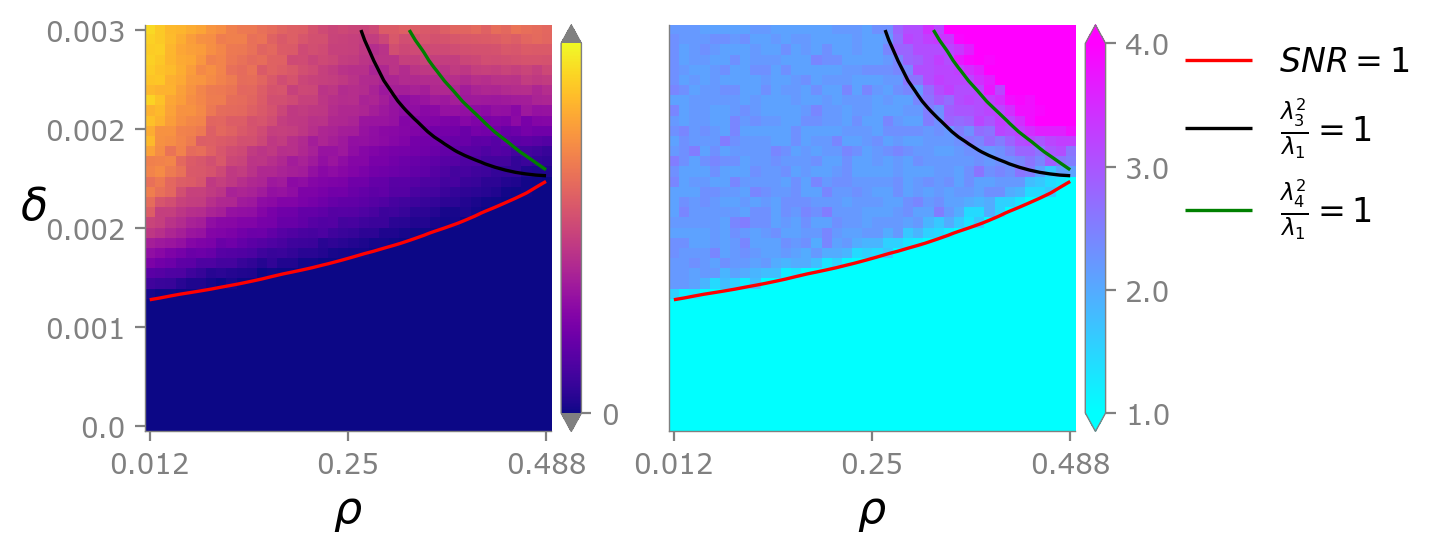

In [4]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=1, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])

handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', cmap=cmap, ax=ax, fig=fig, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# ax.axvline((reso_limit_rho)/(0.5)*np.size(np.unique(plot_rhos)), linestyle=':', lw=1)
lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [5]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
additionId = "BH_learnq_MDL"
fileID = 'amiExp25.2.12' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1, maxz=4, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['1.0', '2.0', '3.0', '4.0']


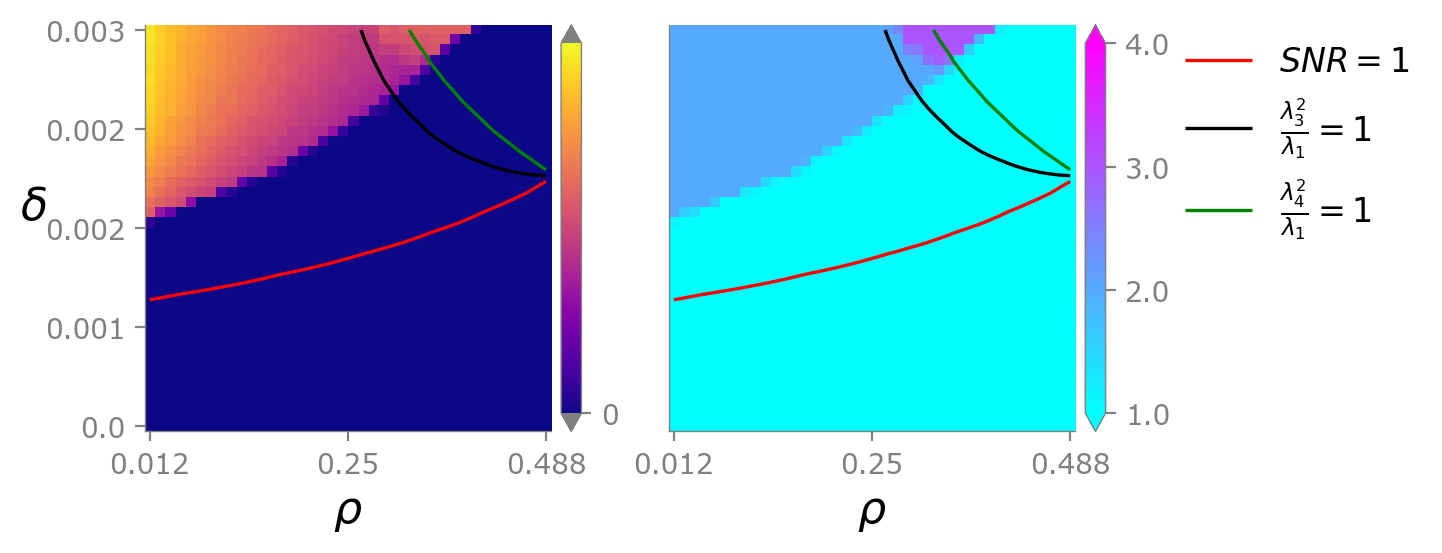

In [6]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=1, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])

handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', min_z=1, max_z=4, cmap=cmap, ax=ax, fig=fig, vmin=1, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# ax.axvline((reso_limit_rho)/(0.5)*np.size(np.unique(plot_rhos)), linestyle=':', lw=1)
lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [4]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = "FE"
givenTrueEpsilon = False
writeCM = False
additionId = "BH_learnq_FE"
fileID = 'amiExp25.2.13' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1, maxz=4, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['1.0', '2.0', '3.0', '4.0']


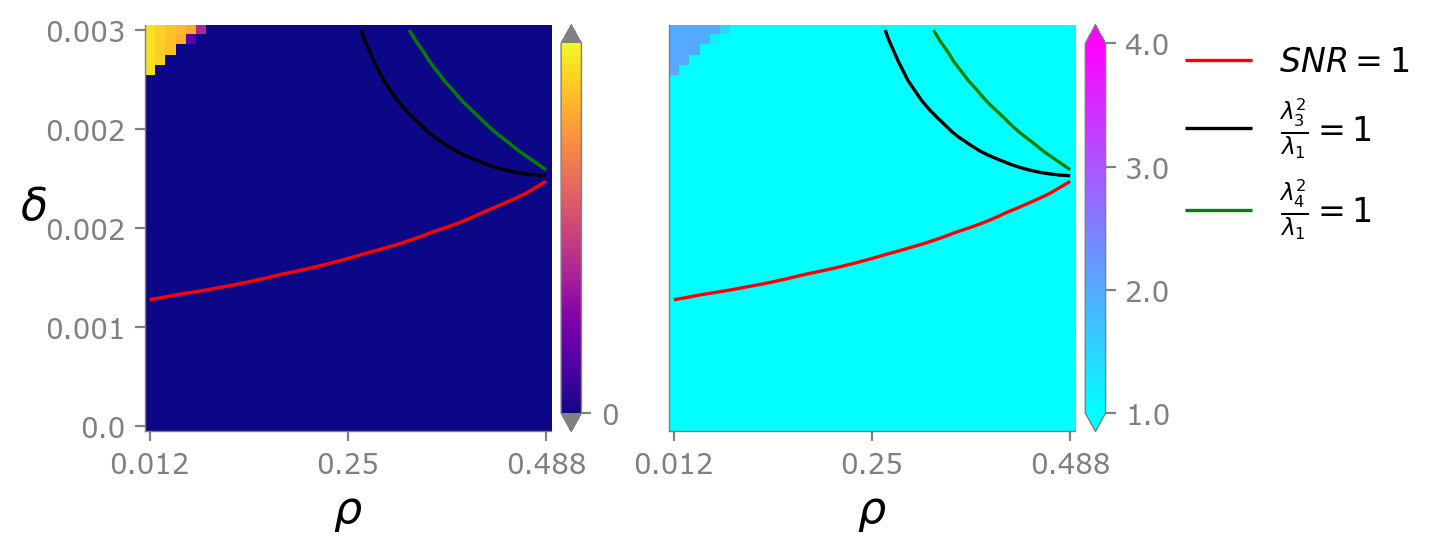

In [5]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=1, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])

handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', min_z=1, max_z=4, cmap=cmap, ax=ax, fig=fig, vmin=1, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# ax.axvline((reso_limit_rho)/(0.5)*np.size(np.unique(plot_rhos)), linestyle=':', lw=1)
lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# plt.subplots_adjust(wspace=0.8)
# save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'Z_s{Z_s}Z_b{Z_b}' + "_half.pdf"
# # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [7]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "BP_learnq_NegEig"
fileID = 'amiExp25.2.13' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1, maxz=4, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['1.0', '2.0', '3.0', '4.0']


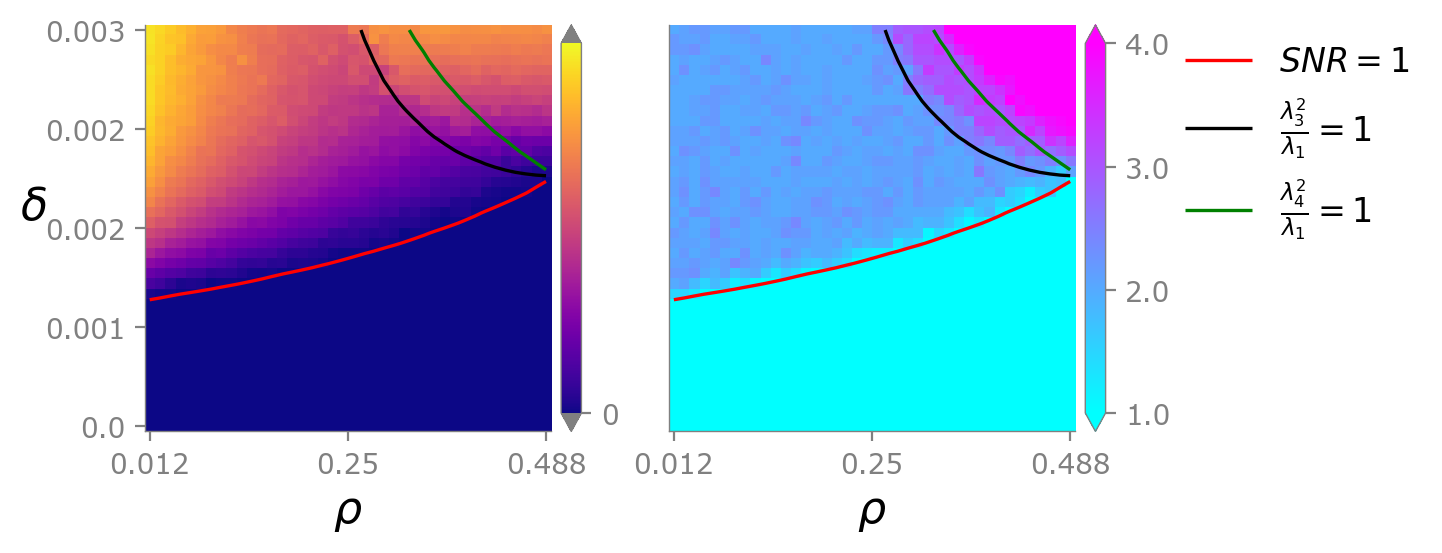

In [8]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=1, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])

handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', min_z=1, max_z=4, cmap=cmap, ax=ax, fig=fig, vmin=1, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# ax.axvline((reso_limit_rho)/(0.5)*np.size(np.unique(plot_rhos)), linestyle=':', lw=1)
lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [9]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
additionId = "BP_learnq_MDL"
fileID = 'amiExp25.2.14' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1, maxz=4, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['1.0', '2.0', '3.0', '4.0']


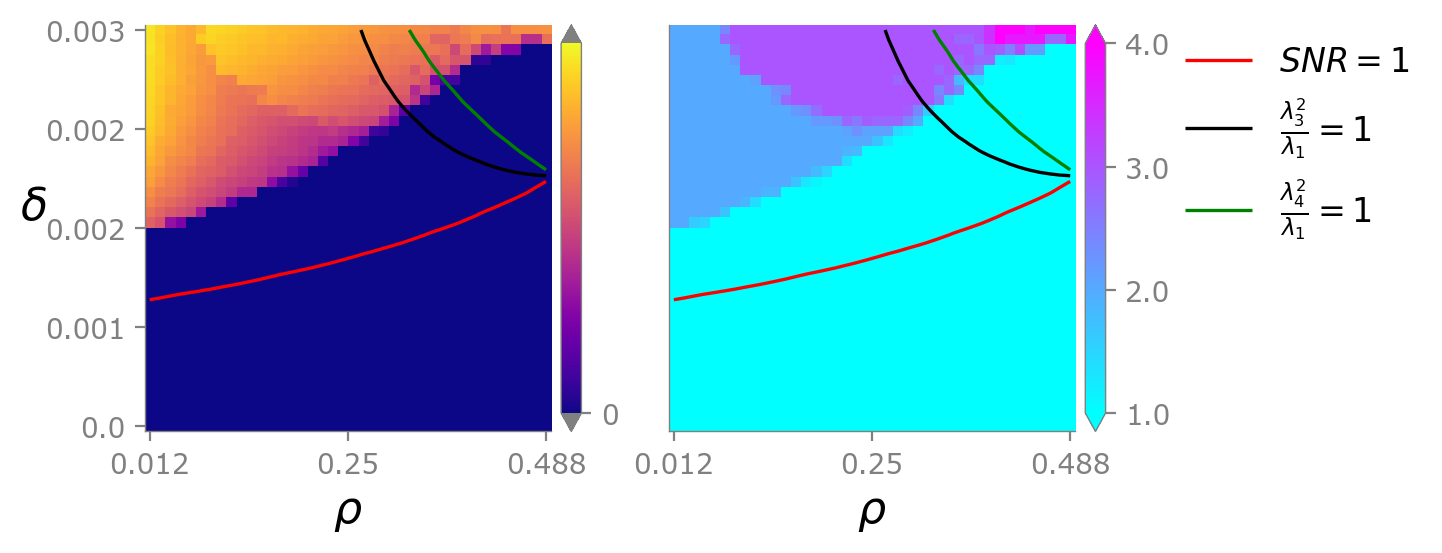

In [10]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=1, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])

handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', min_z=1, max_z=4, cmap=cmap, ax=ax, fig=fig, vmin=1, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# ax.axvline((reso_limit_rho)/(0.5)*np.size(np.unique(plot_rhos)), linestyle=':', lw=1)
lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [11]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = "FE"
givenTrueEpsilon = False
writeCM = False
additionId = "BP_learnq_FE"
fileID = 'amiExp25.2.21' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1, maxz=4, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['1.0', '2.0', '3.0', '4.0']


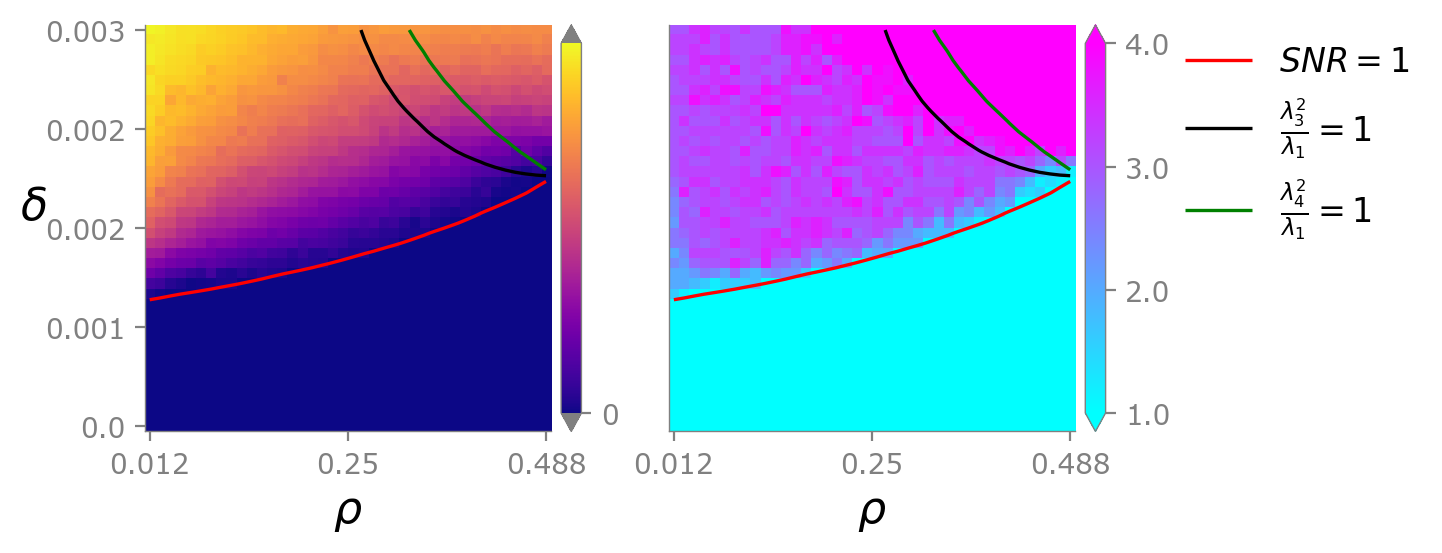

In [12]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=1, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])

handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', min_z=1, max_z=4, cmap=cmap, ax=ax, fig=fig, vmin=1, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# ax.axvline((reso_limit_rho)/(0.5)*np.size(np.unique(plot_rhos)), linestyle=':', lw=1)
lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Compare BP BH when learn q by MDL at some points

In [25]:
def sample_A(n=6000, d=10, Z_s=2, Z_b=2, rho=0.25, delta=0.0025, BP=False):
    q = Z_s + Z_b
    pout = d / n - ((1-rho)**2 / Z_b + rho**2 / Z_s) * delta
    pin = pout + delta
    pin = 0 if pin < 1e-10 else pin
    pout = 0 if pout < 1e-10 else pout
    if BP:
        # For BP not use two small pin and pout
        pin = 1e-5 if pin < 1e-5 else pin
        pout = 1e-5 if pout < 1e-5 else pout
    ps = (pin - pout) * np.identity(q) + pout * np.ones((q, q))
    n_f = int(n * (Z_s + Z_b) * (Z_b * rho + Z_s * (1 - rho)) / (Z_s * Z_b))
    rho_f = Z_b * rho / (Z_b * rho + Z_s * (1 - rho))
    n_fq = int(n_f / q)
    n_f = int(n_fq * q)
    sizes = [[n_fq] * Z_s, [n_fq] * Z_b]
    msbm = MetaSBM(n_f, rho_f, ps, sizes)
    A = msbm.sample()
    metaIdSelect = 0
    filterA, filterGroupId = msbm.filter(A, metaId=metaIdSelect)
    # Get eigenvalue of PQ
    P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
    Q = n * ps
    lambdas = msbm.get_lambdas_general(P, Q)
    print(fr'pin={pin}, pout={pout}, {lambdas[1]**2/lambdas[0]}, {lambdas[2]**2/lambdas[0]}, {lambdas[3]**2/lambdas[0]}')
    return msbm, filterA, filterGroupId

In [40]:
def desc_length_s(A, q, partition):
    N = np.shape(A)[0]
    E = np.sum(A) / 2
    x = q * (q + 1) / (2 * E)
    hx = ((1 + x) * np.log(1 + x) - x * np.log(x))
    Lt = E * hx + N * np.log(q)
    It = 0
    unique_partition = np.unique(partition)
    # St = E
    for r in unique_partition:
        for s in unique_partition:
            r_index = np.where(partition == r)[0]
            s_index = np.where(partition == s)[0]
            n_r = np.size(r_index)
            n_s = np.size(s_index)
            ers = np.sum(A[np.ix_(r_index, s_index)])
            # St -= 1 / 2 * ers * np.log(ers / (n_r * n_s))
            mrs = ers / (2 * E)
            wr = n_r / N
            ws = n_s / N
            It += mrs * np.log(mrs / (wr * ws)) if mrs != 0 else 0
    Epsilonb = Lt - E * It  # equation (6) in "Parsimonious module inference in large networks"
    return Epsilonb, Lt, - E * It

In [35]:
def get_cd_result(A, groupId, BP=False, learnqby="MDL", learnq=1):
    # community detection
    if learnq == 1:
        g = nx.from_scipy_sparse_array(A)
        N = g.number_of_nodes()
        partition = np.array([0 for i in range(N)])
    elif BP:
        partition, _ = CommunityDetect(A).BP(num_groups=learnq, na=None, cab=None, groupId=groupId, processId=os.getpid(), infermode=2, init_epsilon=0.2, learn_conv_crit=None, learn_max_time=None)
    else:
        partition, _ = CommunityDetect(A).BetheHessian(num_groups=learnq)
    ami = adjusted_mutual_info_score(groupId, partition)
    if learnqby == "MDL":
        criteria = desc_length_s(A, learnq, partition)
    return partition, ami, criteria

In [44]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [45]:
def plot_cm(confusionMatrix, fig=None, ax=None):
    subTrueNumgroup,subBHNumgroup = np.shape(confusionMatrix)
    rowsum = np.sum(confusionMatrix, axis=1)
    rowsum = rowsum.reshape(-1, 1)
    rowsum = np.repeat(rowsum, subBHNumgroup, axis=1)
    normConfusionMatrix = np.round(confusionMatrix / rowsum, 2)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(3, 3))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
#     cmap = mpl.colormaps["bwr_r"]
#     cmap = mpl.colormaps["RdYlBu"]
    cmap = mpl.colormaps["seismic_r"]
    cmap = truncate_colormap(cmap, 0.3, 0.7)
    im = ax.matshow(normConfusionMatrix, cmap=cmap, vmin=0, vmax=1)
    for i in range(subTrueNumgroup):
        for j in range(subBHNumgroup):
            c = normConfusionMatrix[i,j]
            ax.text(j, i, str(c), va='center', ha='center', fontsize=12)
#     ax.set_title(rf"$\rho={rho}, \delta={delta}$", fontsize=12)
    # ax.set_ylabel("True Community", rotation='horizontal', fontsize=20)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    return im

In [51]:
n=6000
d=10
Z_s=2
Z_b=2
rho=0.25
delta=0.00299
msbm, A, groupId = sample_A(n=n, d=d, Z_s=Z_s, Z_b=Z_b, rho=rho, delta=delta)

Metadata generation done!
pin=0.0037222916666666667, pout=0.0007322916666666668, 4.299531960877118, 0.7647022768205424, 0.47772577343079037


True index is [3], Community detected index is [0]
learnq=1, ami=0.0, DL=(11.295141051262702, 11.295141051262702, -0.0)
True index is [2 3], Community detected index is [0 1]
learnq=2, ami=0.4496901011080754, DL=(-1312.256758136813, 4169.371502799098, -5481.628260935911)
True index is [0 2 3], Community detected index is [2 0 1]
learnq=3, ami=0.30382333760726693, DL=(705.1639437154145, 6616.834772051785, -5911.6708283363705)
True index is [0 1 2 3], Community detected index is [0 2 1 3]
learnq=4, ami=0.22392593592399307, DL=(2536.2363771938344, 8367.49071052793, -5831.254333334096)


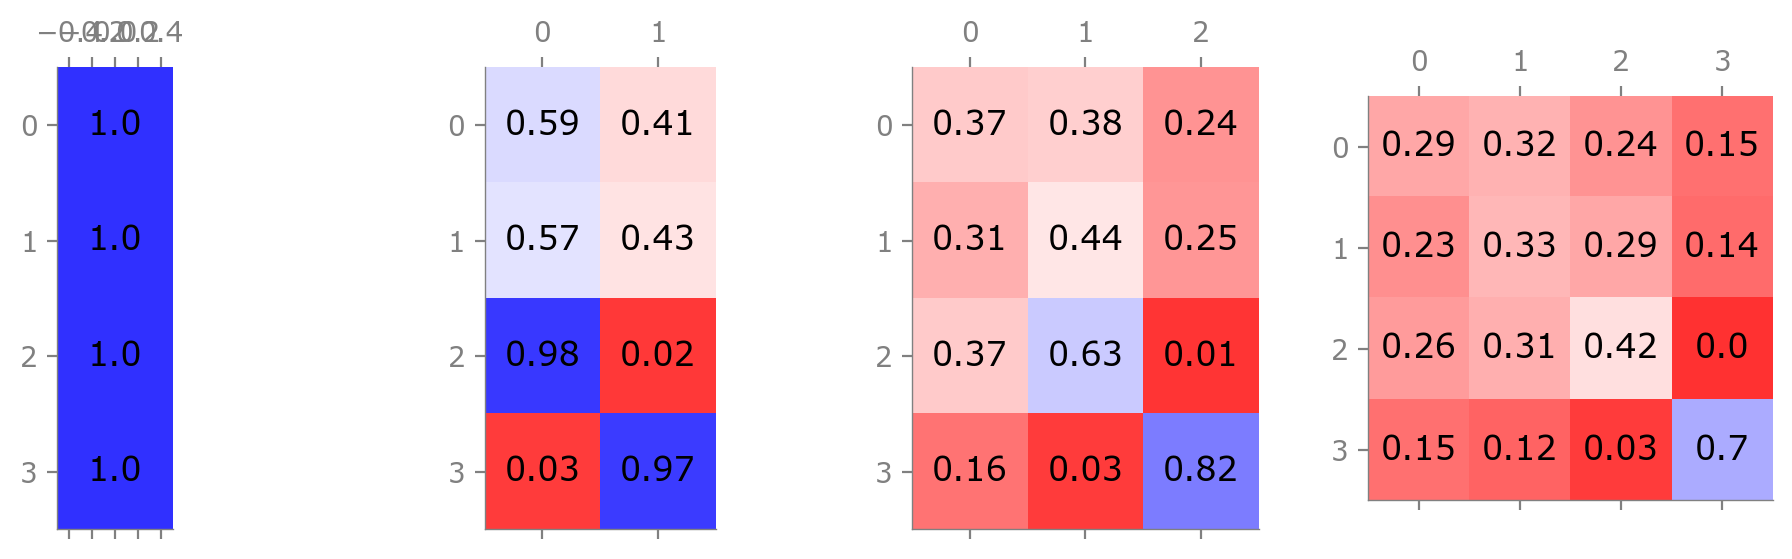

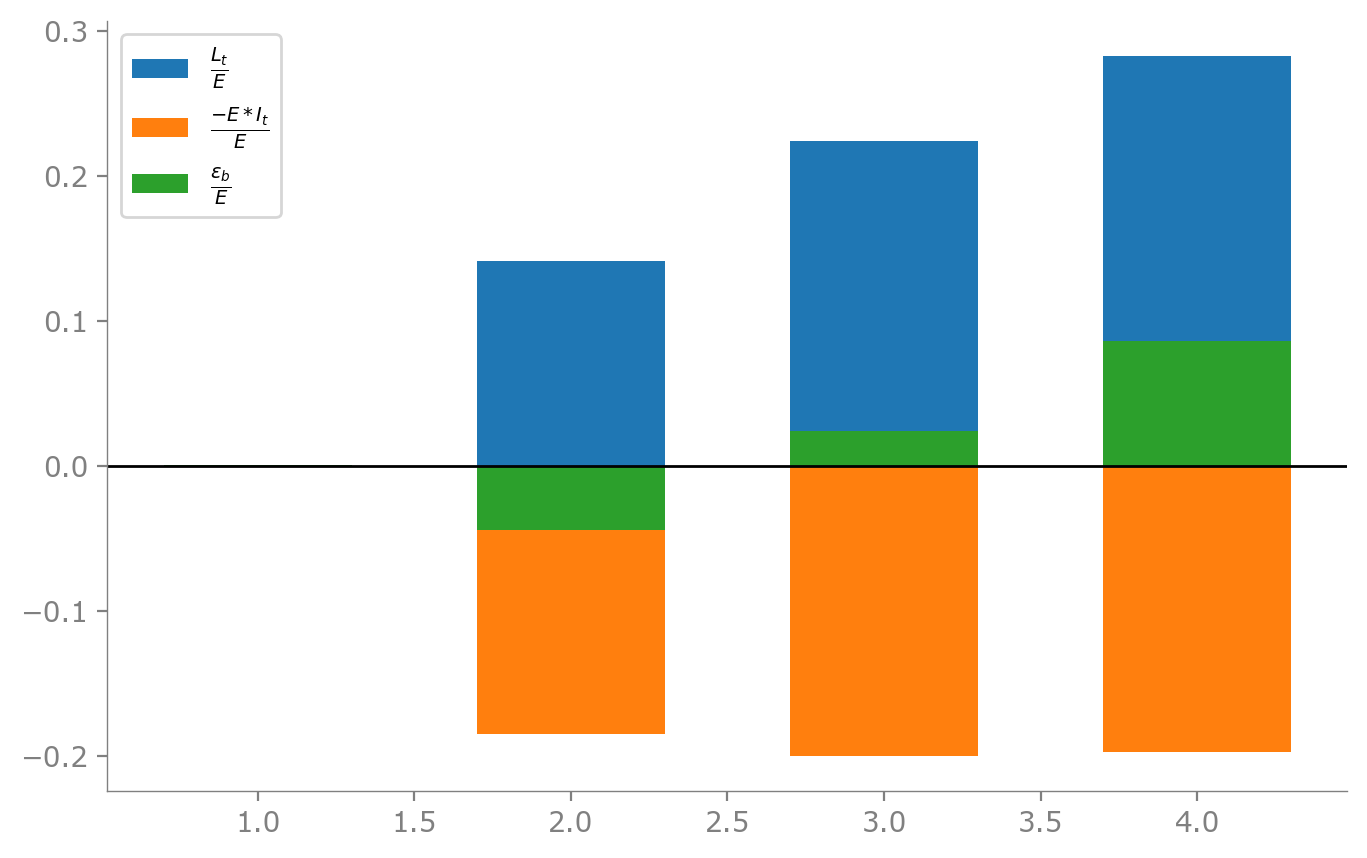

In [59]:
q = Z_s + Z_b
E = np.sum(A) / 2
BP = False

Epsilon_b_over_E = []
Lt_over_E = []
It_over_E = []

fig = plt.figure(figsize=(12, 3))
widths = [3, 3, 3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=4, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
for learnq in range(1, 5):
    # here criteria include Epsilonb, Lt part(without partition) and It part(with partition)
    partition, ami, criteria = get_cd_result(A, groupId, BP=BP, learnqby="MDL", learnq=learnq)  
    # Output confusion matrix and ami
    confusionMatrix, _ = get_confusionmatrix(groupId, partition, q, learnq)
    col = learnq - 1 
    ax = fig.add_subplot(spec5[row, col])
    plot_cm(confusionMatrix, fig=fig, ax=ax)
    print(f'learnq={learnq}, ami={ami}, DL={criteria}')
    # save desc length
    Epsilon_b_over_E.append(criteria[0] / E)
    Lt_over_E.append(criteria[1] / E)
    It_over_E.append(criteria[2] / E)

fig, ax = plt.subplots()
bottom = np.zeros(4)
width = 0.6  # the width of the bars: can also be len(x) sequence
p = ax.bar(list(range(1, 5)), Lt_over_E, width, label=r'$\frac{L_t}{E}$', bottom=bottom)
p = ax.bar(list(range(1, 5)), It_over_E, width, label=r'$\frac{-E*I_t}{E}$', bottom=bottom) 
p = ax.bar(list(range(1, 5)), Epsilon_b_over_E, width, label=r'$\frac{\epsilon_b}{E}$', bottom=bottom)
ax.axhline(0, color='k', lw=1)
ax.legend()


True index is [3], Community detected index is [0]
learnq=1, ami=0.0, DL=(11.295141051262702, 11.295141051262702, -0.0)
./other/mode_net/sbm learn -l ./other/mode_net/data/temp2876.gml -n5971 -q2 -P0.2,9.91 -M ./other/mode_net/data/marginal2876.txt -v-1 -E1e-06 -T1000


FileNotFoundError: [Errno 2] No such file or directory: './other/mode_net/data/marginal2876.txt'

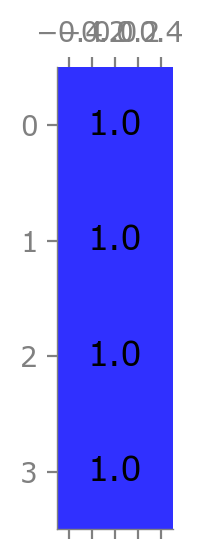

In [62]:
q = Z_s + Z_b
E = np.sum(A) / 2
BP = True

Epsilon_b_over_E = []
Lt_over_E = []
It_over_E = []

fig = plt.figure(figsize=(12, 3))
widths = [3, 3, 3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=4, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
for learnq in range(1, 5):
    # here criteria include Epsilonb, Lt part(without partition) and It part(with partition)
    partition, ami, criteria = get_cd_result(A, groupId, BP=BP, learnqby="MDL", learnq=learnq)  
    # Output confusion matrix and ami
    confusionMatrix, _ = get_confusionmatrix(groupId, partition, q, learnq)
    col = learnq - 1 
    ax = fig.add_subplot(spec5[row, col])
    plot_cm(confusionMatrix, fig=fig, ax=ax)
    print(f'learnq={learnq}, ami={ami}, DL={criteria}')
    # save desc length
    Epsilon_b_over_E.append(criteria[0] / E)
    Lt_over_E.append(criteria[1] / E)
    It_over_E.append(criteria[2] / E)

fig, ax = plt.subplots()
bottom = np.zeros(4)
width = 0.6  # the width of the bars: can also be len(x) sequence
p = ax.bar(list(range(1, 5)), Lt_over_E, width, label=r'$\frac{L_t}{E}$', bottom=bottom)
p = ax.bar(list(range(1, 5)), It_over_E, width, label=r'$\frac{-E*I_t}{E}$', bottom=bottom) 
p = ax.bar(list(range(1, 5)), Epsilon_b_over_E, width, label=r'$\frac{\epsilon_b}{E}$', bottom=bottom)
ax.axhline(0, color='k', lw=1)
ax.legend()


In [64]:
os.system("./other/mode_net/sbm learn -l ./other/mode_net/data/temp2876.gml -n5971 -q2 -P0.2,9.91 -M ./other/mode_net/data/marginal2876.txt -v-1 -E1e-06 -T1000")

1

In [65]:
os.getcwd()

'D:\\Work\\PhD\\_code\\_nodeclassification'

In [74]:
import subprocess
subprocess.run("./other/mode_net/sbm learn -l ./other/mode_net/data/temp2876.gml -n5971 -q2 -P0.2,9.91 -M ./other/mode_net/data/marginal2876.txt -v-1 -E1e-06 -T1000", 
              shell=True, capture_output=True, text=True)

CompletedProcess(args='./other/mode_net/sbm learn -l ./other/mode_net/data/temp2876.gml -n5971 -q2 -P0.2,9.91 -M ./other/mode_net/data/marginal2876.txt -v-1 -E1e-06 -T1000', returncode=1, stdout='', stderr="'.' 不是内部或外部命令，也不是可运行的程序\n或批处理文件。\n")